In [4]:
import pandas as pd
df = pd.read_csv(r"C:\Users\appuv\Desktop\internship\omnichannel_retail_dataset1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     500 non-null    int64 
 1   order_date   500 non-null    object
 2   product      500 non-null    object
 3   category     500 non-null    object
 4   city         500 non-null    object
 5   channel      500 non-null    object
 6   quantity     500 non-null    int64 
 7   price        500 non-null    int64 
 8   total_sales  500 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 35.3+ KB


In [5]:
(df.shape)

(500, 9)

In [6]:
df.head(5)

,order_id,order_date,product,category,city,channel,quantity,price,total_sales
0,1000,05-12-2025 14:00,Backpack,Accessories,Hyderabad,Offline,2,11899,23798
1,1001,02-03-2025 15:00,Laptop,Electronics,Hyderabad,Offline,1,8114,8114
2,1002,31-08-2025 07:00,Backpack,Accessories,Hyderabad,Offline,4,4314,17256
3,1003,27-11-2025 19:00,Headphones,Electronics,Chennai,Online,2,33969,67938
4,1004,08-03-2025 15:00,Smartphone,Electronics,Bangalore,Online,3,42462,127386


In [7]:
df.describe()

,order_id,quantity,price,total_sales
count,500.000000,500.000000,500.000000,500.000000
mean,1249.500000,3.000000,24788.272000,72825.460000
std,144.481833,1.382687,14693.127133,57959.433027
min,1000.000000,1.000000,681.000000,1491.000000
25%,1124.750000,2.000000,11555.250000,28736.750000
50%,1249.500000,3.000000,24541.000000,53826.500000
75%,1374.250000,4.000000,38103.000000,108420.750000
max,1499.000000,5.000000,49955.000000,249280.000000


In [8]:
df.isnull()

,order_id,order_date,product,category,city,channel,quantity,price,total_sales
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False


price: 0 outliers | Bounds: ₹-28,266 to ₹77,925


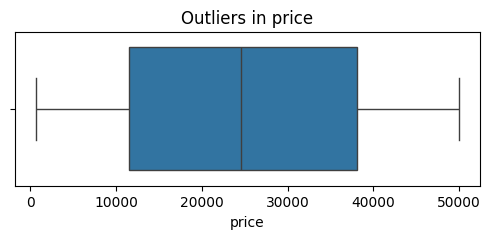

quantity: 0 outliers | Bounds: ₹-1 to ₹7


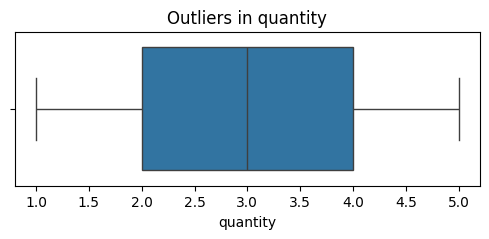

total_sales: 9 outliers | Bounds: ₹-90,789 to ₹227,947


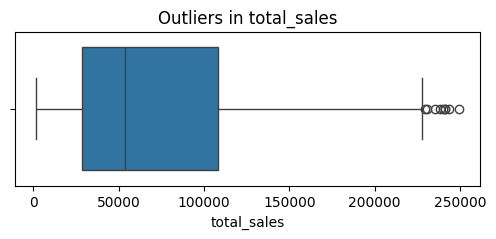

In [9]:
                                # Checking Outliers

import matplotlib.pyplot as plt
import seaborn as sns

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | Bounds: ₹{lower:,.0f} to ₹{upper:,.0f}")
    return outliers, lower, upper

# Check key numeric columns
for col in ['price', 'quantity', 'total_sales']:
    outliers, low, high = detect_outliers_iqr(df, col)
    
    # Boxplot to visualize
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

In [10]:
# Total revenue
print("Total Sales: ₹", df['total_sales'].sum())

Total Sales: ₹ 36412730


In [11]:
# Top 5 products by revenue
top_products = df.groupby('product')['total_sales'].sum().sort_values(ascending=False).head()
print(top_products)

product
Laptop     5374622
Watch      5048915
T-shirt    4876114
Tablet     4611786
Shoes      4475817
Name: total_sales, dtype: int64


In [12]:
# Online vs Offline sales
channel_sales = df.groupby('channel')['total_sales'].sum()
print(channel_sales)

channel
Offline    18802277
Online     17610453
Name: total_sales, dtype: int64


In [13]:
# Sales by city
city_sales = df.groupby('city')['total_sales'].sum().sort_values(ascending=False)
print(city_sales)

city
Mumbai       6792574
Hyderabad    6756808
Delhi        6552147
Bangalore    6020689
Chennai      5346027
Pune         4944485
Name: total_sales, dtype: int64


In [14]:
# Category performance 
category_sales = df.groupby('category')['total_sales'].sum()
print(category_sales)

category
Accessories     8737014
Electronics    18323785
Fashion         9351931
Name: total_sales, dtype: int64


In [15]:
# Average order value
aov = df['total_sales'].mean()
print("Average Order Value: ₹", round(aov, 2))

Average Order Value: ₹ 72825.46


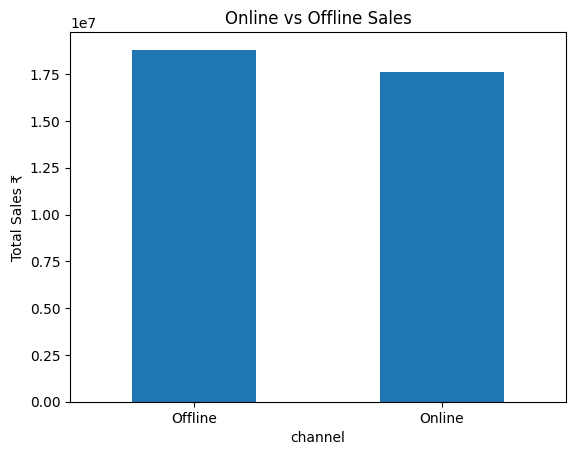

In [16]:
import matplotlib.pyplot as plt

# Sales by channel bar chart
df.groupby('channel')['total_sales'].sum().plot(kind='bar', title='Online vs Offline Sales')
plt.ylabel('Total Sales ₹')
plt.xticks(rotation=0)
plt.show()


In [17]:
#Offline sales by city
offline_city = df[df['channel']=='Offline'].groupby('city')['total_sales'].sum().sort_values()
print("Offline sales by city - lowest first:")
print(offline_city)



Offline sales by city - lowest first:
city
Pune         2697403
Bangalore    2803350
Hyderabad    3103265
Delhi        3235160
Chennai      3334816
Mumbai       3628283
Name: total_sales, dtype: int64


In [18]:
                                       # Revenue % by city for Offline
offline_total = offline_city.sum()
print("\n% share of Offline revenue:")
print((offline_city / offline_total * 100).round(2))


% share of Offline revenue:
city
Pune         14.35
Bangalore    14.91
Hyderabad    16.50
Delhi        17.21
Chennai      17.74
Mumbai       19.30
Name: total_sales, dtype: float64


Product by channel:
channel     Offline  Online  Online_%  Offline_%
product                                         
Tablet           92     113      55.1       44.9
Shoes            90      98      52.1       47.9
T-shirt          92      99      51.8       48.2
Backpack         74      76      50.7       49.3
Headphones       87      86      49.7       50.3
Laptop          111     107      49.1       50.9
Smartphone       99      82      45.3       54.7
Watch           116      78      40.2       59.8


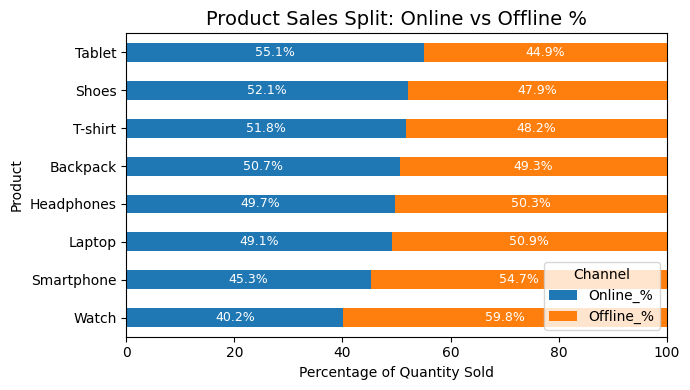

In [19]:
                                       # Inventory allocation by channel.

product_channel = pd.pivot_table(df, values='quantity', index='product', 
                                 columns='channel', aggfunc='sum', fill_value=0)
total = product_channel[['Online', 'Offline']].sum(axis=1)
product_channel['Online_%'] = (product_channel['Online'] / total * 100).round(1)
product_channel['Offline_%'] = (product_channel['Offline'] / total * 100).round(1)
print("Product by channel:")
print(product_channel.sort_values('Online_%', ascending=False).round(1))


plot_data = product_channel.sort_values('Online_%', ascending=True)
ax = plot_data[['Online_%', 'Offline_%']].plot(
    kind='barh', 
    stacked=True, 
    figsize=(7, 4),
    color=['#1f77b4', '#ff7f0e']  
)
plt.title('Product Sales Split: Online vs Offline %', fontsize=14)
plt.xlabel('Percentage of Quantity Sold')
plt.ylabel('Product')
plt.legend(title='Channel', loc='lower right')
plt.xlim(0, 100)

for i, (online, offline) in enumerate(zip(plot_data['Online_%'], plot_data['Offline_%'])):
    if online > 5:  # Only label if bar segment is big enough
        plt.text(online/2, i, f'{online}%', ha='center', va='center', color='white', fontsize=9)
    if offline > 5:
        plt.text(online + offline/2, i, f'{offline}%', ha='center', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()


 SKUs driving 80% revenue: 6 out of 8
product
Laptop        5374622
Watch         5048915
T-shirt       4876114
Tablet        4611786
Shoes         4475817
Smartphone    4323113
Name: total_sales, dtype: int64


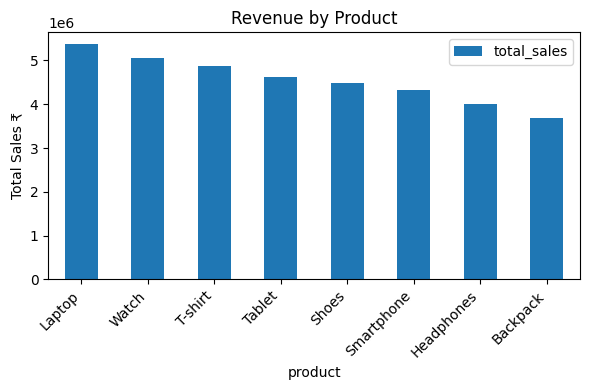

In [43]:
                              # Total Revenue by Product

product_rev = df.groupby('product')['total_sales'].sum().sort_values(ascending=False)
cumulative_pct = product_rev.cumsum() / product_rev.sum() * 100
hero_skus = product_rev[cumulative_pct <= 80]

print(f" SKUs driving 80% revenue: {len(hero_skus)} out of {len(product_rev)}")
print(hero_skus)

plt.figure(figsize=(6,4))
product_rev.plot(kind='bar')
plt.title('Revenue by Product')
plt.ylabel('Total Sales ₹')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

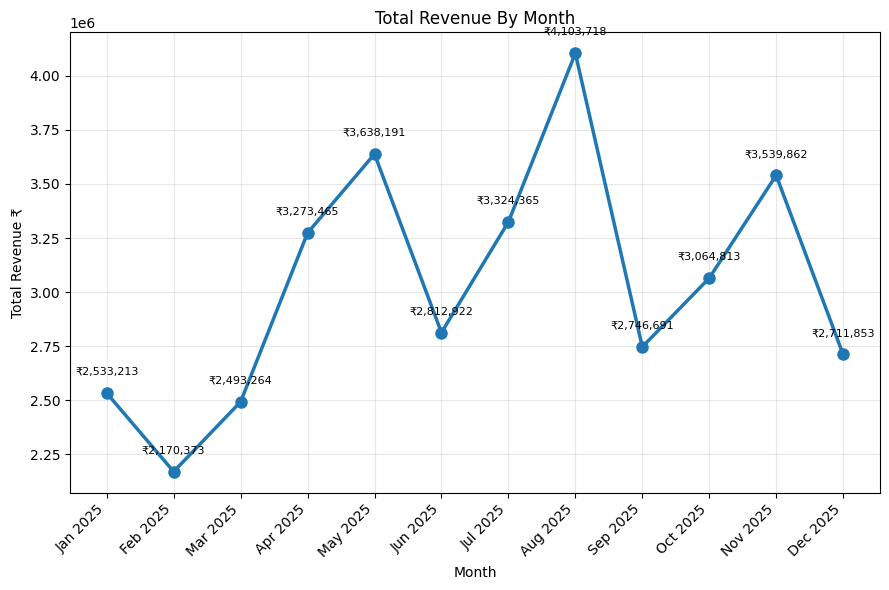

In [51]:
                                      # Total Revenue by Month

df_2025 = df[df['order_date'].dt.year == 2025].copy()
df_2025['month_year'] = df_2025['order_date'].dt.strftime('%b %Y')
df_2025['sort_key'] = df_2025['order_date'].dt.to_period('M')

monthly_2025 = df_2025.groupby(['sort_key', 'month_year'])['total_sales'].sum().reset_index()
monthly_2025 = monthly_2025.sort_values('sort_key')

peak_idx = monthly_2025['total_sales'].idxmax()
low_idx = monthly_2025['total_sales'].idxmin()
peak_month = monthly_2025.loc[peak_idx]
low_month = monthly_2025.loc[low_idx]

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(monthly_2025['month_year'], monthly_2025['total_sales'], 
        marker='o', linewidth=2.5, color='#1f77b4', markersize=8)

plt.title('Total Revenue By Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ₹')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

for i, row in monthly_2025.iterrows():
    ax.text(i, row['total_sales'] + monthly_2025['total_sales'].max()*0.02, 
            f'₹{row["total_sales"]:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

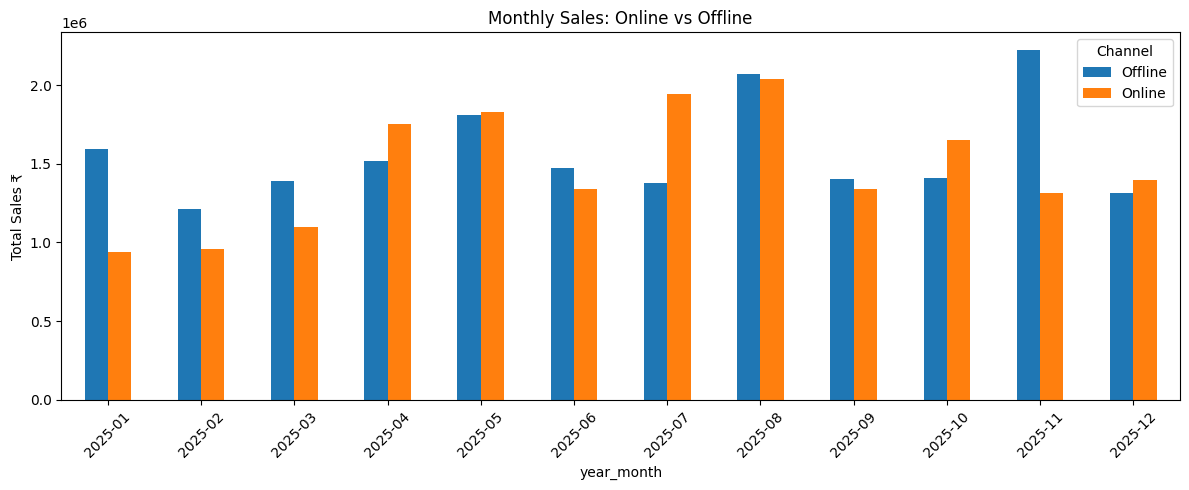

In [78]:
                                   #Total Monthly sales by Online vs Offline

monthly_by_channel = df.groupby(['year_month', 'channel'])['total_sales'].sum().unstack()
monthly_by_channel.plot(kind='bar', figsize=(12,5))
plt.title('Monthly Sales: Online vs Offline')
plt.ylabel('Total Sales ₹')
plt.xticks(rotation=45)
plt.legend(title='Channel')
plt.tight_layout()
plt.show()

20:55:16 - cmdstanpy - INFO - Chain [1] start processing


Last actual: Dec 2025 = ₹2,711,853
Total months of history: 12
Avg monthly revenue: ₹3,034,394


Handoff check:
Dec 2025 actual: ₹2,711,853
Jan 2026 forecast: ₹2,581,312
Jump: -4.8%


20:55:16 - cmdstanpy - INFO - Chain [1] done processing


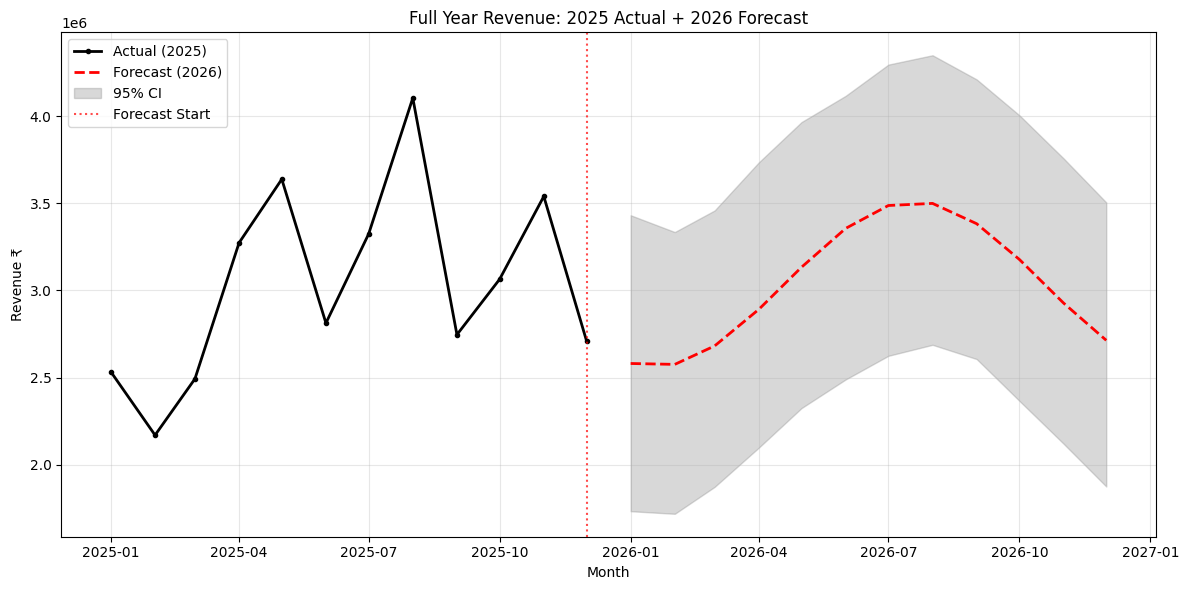

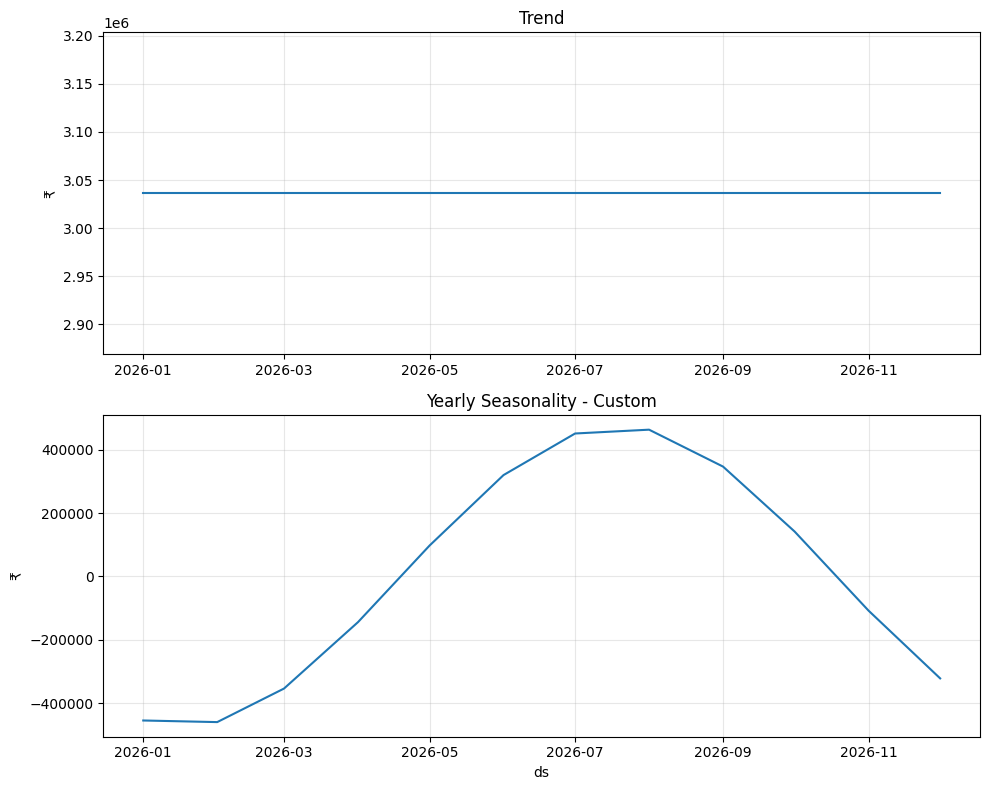


2026 Revenue Forecast:
   Month  Forecast ₹  Lower 95% ₹  Upper 95% ₹
Jan 2026   2581312.0    1734213.0    3431511.0
Feb 2026   2576229.0    1719326.0    3335155.0
Mar 2026   2682165.0    1873847.0    3459083.0
Apr 2026   2891809.0    2098694.0    3734830.0
May 2026   3133615.0    2325590.0    3965878.0
Jun 2026   3356156.0    2489742.0    4116416.0
Jul 2026   3487418.0    2625411.0    4295476.0
Aug 2026   3499485.0    2688468.0    4349094.0
Sep 2026   3382931.0    2606731.0    4210502.0
Oct 2026   3177933.0    2366950.0    4004885.0
Nov 2026   2928091.0    2121560.0    3757709.0
Dec 2026   2714251.0    1875885.0    3505115.0


In [52]:
                                         # Next 12 Month Revenue Using Prophet Regression


import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt


df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y %H:%M')
monthly_df = df.groupby(pd.Grouper(key='order_date', freq='MS'))['total_sales'].sum().reset_index()
monthly_df = monthly_df.rename(columns={'order_date': 'ds', 'total_sales': 'y'})

last_date = monthly_df['ds'].max()
last_value = monthly_df['y'].iloc[-1]
print(f"Last actual: {last_date.strftime('%b %Y')} = ₹{last_value:,.0f}")
print(f"Total months of history: {len(monthly_df)}")
print(f"Avg monthly revenue: ₹{monthly_df['y'].mean():,.0f}\n")

print(f"\nHandoff check:")
print(f"Dec 2025 actual: ₹{last_value:,.0f}")
print(f"Jan 2026 forecast: ₹{forecast_2026['Forecast ₹'].iloc[0]:,.0f}")
print(f"Jump: {(forecast_2026['Forecast ₹'].iloc[0]/last_value - 1)*100:.1f}%")

m = Prophet(
    growth='flat',
    yearly_seasonality=False, 
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.001,
    uncertainty_samples=1000,
    interval_width=0.95
)
m.add_seasonality(name='yearly_custom', period=365.25, fourier_order=1) # period=365.25 NOT 30.5
m.fit(monthly_df)
future = pd.DataFrame({
    'ds': pd.date_range(
        start=last_date + pd.offsets.MonthBegin(1),
        periods=12, 
        freq='MS'
    )
})
forecast = m.predict(future)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(monthly_df['ds'], monthly_df['y'], 'k.-', markersize=6, linewidth=2, label='Actual (2025)')
ax.plot(forecast['ds'], forecast['yhat'], 'r--', linewidth=2, label='Forecast (2026)')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                color='gray', alpha=0.3, label='95% CI')
ax.axvline(last_date, color='red', linestyle=':', alpha=0.7, label='Forecast Start')
plt.title('Full Year Revenue: 2025 Actual + 2026 Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue ₹')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig2, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(forecast['ds'], forecast['trend'])
axes[0].set_title('Trend')
axes[0].set_ylabel('₹')
axes[0].grid(True, alpha=0.3)

axes[1].plot(forecast['ds'], forecast['yearly_custom'])
axes[1].set_title('Yearly Seasonality - Custom')
axes[1].set_ylabel('₹')
axes[1].set_xlabel('ds')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
forecast_2026 = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_2026['month'] = forecast_2026['ds'].dt.strftime('%b %Y')
forecast_2026 = forecast_2026[['month', 'yhat', 'yhat_lower', 'yhat_upper']].round(0)
forecast_2026.columns = ['Month', 'Forecast ₹', 'Lower 95% ₹', 'Upper 95% ₹']

print("\n2026 Revenue Forecast:")
print(forecast_2026.to_string(index=False))




The forecast indicates a stable but slightly declining start to 2026, with January revenue about 4.8% lower than December 2025.
Suggesting short-term softening in demand. Howerevenues gradually recover and peak mid-year (July–August) before tapering again, reflecting a moderate seasonal pattern rather than strong growth. Overall, the model suggests steady performance with limited volatility, suitable for conservative business planning.